In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

In [1]:
from maui_analysis.data_alignment import *

synced_data_hf = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/synced_data.h5'
timestamp_csv = '/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/'
slices = 11

save_path = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/aligned_data.h5'


# # def align_scopetimes_to_behaviortimes(timestamp_csv, synced_data_hf, slices_per_vol):
volume_times = convert_scope_frametimes_to_volumetimes(timestamp_csv, slices)
# # open h5 with walk times
# print('Volume times:', volume_times)
walk_times, _ = open_processed_behavior_data(synced_data_hf)
# # find last index where behavior time and scope times align
last_index = np.argmax(volume_times > max(walk_times))
aligned_scopetimes = volume_times[:last_index]

<KeysViewHDF5 ['behavior timestamps', 'fly speed']>


In [2]:
print(volume_times)
print(last_index)

[2.32701818e+02 6.64527273e+02 1.09634000e+03 ... 1.19900356e+06
 1.19943538e+06 1.19986721e+06]
2778


In [4]:

aligned_scopetimes = align_scopetimes_to_behaviortimes(timestamp_csv, synced_data_hf, slices)

walk_times, walk_speeds = open_processed_behavior_data(synced_data_hf)

<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>


In [3]:
behavior_downsampled = downsample_behavior_to_scope(walk_times, aligned_scopetimes)

2778 2778


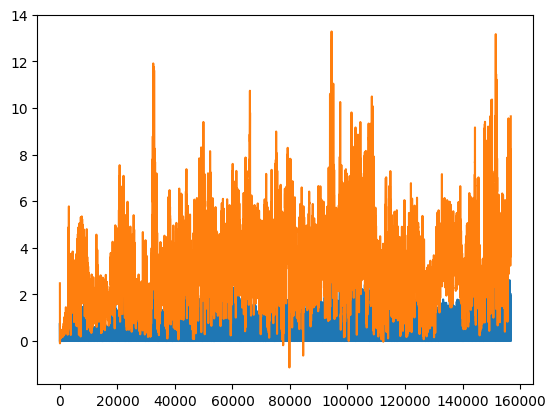

In [3]:
dat_file = '/Volumes/AhmedLab/princess/data/pIP10_GC8m_fly03_win02_trial01/side_video_2026-04-25T11_12_11-20260722_170212.dat'


def pull_fictrac_speed(dat_file, camera_framerate = 130, smoothing_window_s = 0.5):
    speed_df = pd.DataFrame(pd.read_csv(dat_file, header=None)) # radians/frame

    # calculate speed in mm/s, where mm = arc length
    # arc length = radius * radians
    ball_radius = 4.5 # mm
    inst_speed = speed_df[18] * ball_radius * camera_framerate # mm/s

    window_size = int(smoothing_window_s * camera_framerate)
    speed_smoothed = savgol_filter(inst_speed, window_size, polyorder=3)
    return speed_smoothed

dat_dataframe = pd.DataFrame(pd.read_csv(dat_file, header=None))
inst_speed = np.rad2deg(dat_dataframe[18])
fly_speed = pull_fictrac_speed(dat_file, camera_framerate = 130)
plt.plot(inst_speed)
plt.plot(fly_speed)

In [15]:
from maui_codebook import timesync

In [17]:
# camera timestamps
ttl_csv_path = '/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/'

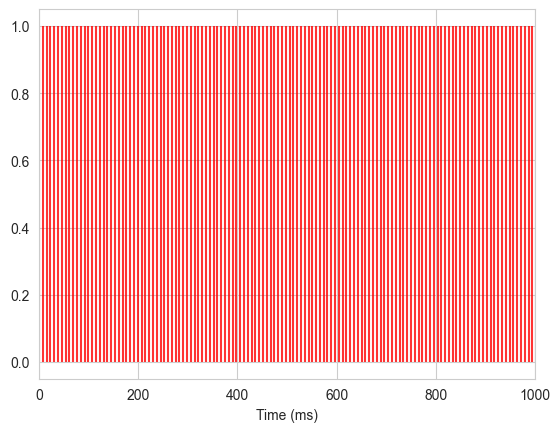

In [5]:

ts = timesync.extract_camera_timestamps(ttl_csv, plot=True)

In [8]:
# OK, there are extra ttls recorded after the video finishes
# - the camera is still running and outputting ttls, but the video has stopped being written
# need to remove the excess camera frames for analysis

In [21]:
from scipy.interpolate import interp1d
# y = f(x) == speed = f(time)
f = interp1d(speed_ts, fly_speed)

In [40]:
ind = np.argmax(scope_ts > max(speed_ts))
print(ind)

30554


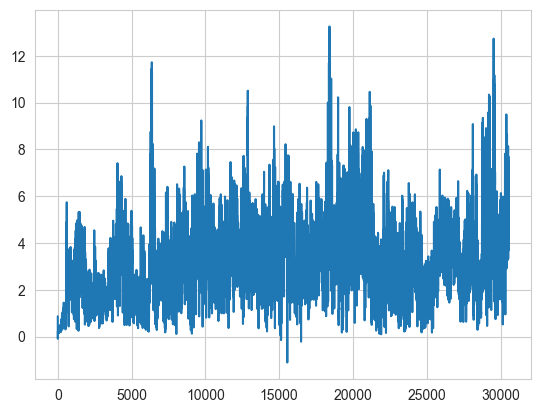

In [41]:
speed_new = f(scope_ts[:ind])
plt.plot(speed_new)

In [6]:
from maui_analysis import process_behavior

ttl_csv = '/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001_Cycle00001_VoltageRecording_001.csv'

process_behavior.save_speed_data(dat_file, ttl_csv, save_path='/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/')



In [69]:
import h5py
path = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/synced_data.h5'

with h5py.File(path, 'r') as f:
    print(f.keys())
    walk_ts = f['behavior timestamps'][...]
    walk_sp = f['fly speed'][...]

<KeysViewHDF5 ['behavior timestamps', 'fly speed']>


In [27]:
# 1. load signal h5
file = '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001/20_supervoxels.h5'
with h5py.File(file, "r") as f:
    cluster_labels = f["labels"][...]
    signal = f["signal"][...]
    print(f.keys())

# scope_ts = timesync.extract_scope_timestamps(ttl_csv_path).squeeze()


<KeysViewHDF5 ['labels', 'signal']>


In [64]:
scope_frames = scope_ts
scope_volumes = np.reshape(scope_frames, [-1,11])
print(scope_volumes.shape)
print(scope_volumes[3])
avg_vol_t = np.mean(scope_volumes, axis = 1)
print(avg_vol_t.shape)

(2779, 11)
[1362.06 1395.26 1428.48 1461.68 1494.88 1528.22 1561.42 1594.64 1627.84
 1661.06 1694.26]
(2779,)


In [32]:
import numpy as np
from maui_codebook import timesync

def convert_scope_frametimes_to_volumetimes(timestamp_csv, slices_per_vol):
    frame_timestamps = timesync.extract_scope_timestamps(timestamp_csv).squeeze()
    reshape_to_volumes = np.reshape(frame_timestamps, [slices_per_vol, -1])
    return np.mean(reshape_to_volumes, axis = 0)

(11, 2779)
(2779,)


In [36]:
import xarray as xr
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': avg_vol_t}
)

print(signal_xr)

<xarray.DataArray (zposs: 11, roi: 20, time: 2779)> Size: 5MB
array([[[-2.40345421e-01, -1.44517449e-01,  2.03607169e-01, ...,
         -2.51148064e-01, -2.51148064e-01, -2.51148064e-01],
        [-2.16749557e-01, -1.96370647e-01, -1.18749183e-01, ...,
         -2.18567971e-01, -2.18631855e-01, -2.18631855e-01],
        [-1.69858322e-01, -1.10973198e-01,  1.13143961e-01, ...,
         -1.75297856e-01, -1.75297856e-01, -1.75297856e-01],
        ...,
        [-4.13397678e-02, -4.13397678e-02, -4.13397678e-02, ...,
         -4.13397678e-02, -4.13397678e-02, -4.13397678e-02],
        [-8.24225244e-02, -8.24225244e-02, -8.24225244e-02, ...,
         -8.24225244e-02, -8.24225244e-02, -8.24225244e-02],
        [-4.28364051e-02, -4.28364051e-02, -4.28364051e-02, ...,
         -4.28364051e-02, -4.28364051e-02, -4.28364051e-02]],

       [[ 6.60829063e-01,  5.81965747e-01,  5.74789653e-01, ...,
         -4.54437641e-01, -4.54570173e-01, -4.54570173e-01],
        [ 2.47562609e-01,  2.52185842e-01

ptodo

take mean timestamp of the volume
downsample behavior to volume time
interpolate behavior to calcium activity times

In [76]:
print(walk_ts.shape, avg_vol_t.shape)
print(walk_ts[-1], avg_vol_t[-3])

(156793,) (2779,)
1199493.42 1199003.5618181818


In [79]:
last_t = np.argmax(avg_vol_t > max(walk_ts))
print(last_t)
aligned_scope_ts = avg_vol_t[:last_t]

2778


In [ ]:
# determine
from scipy.interpolate import interp1d

# y = f(x) == speed = f(time)
f = interp1d(speed_ts, fly_speed)
ind = np.argmax(scope_ts > max(speed_ts))
print(ind)
speed_new = f(scope_ts[:ind])
plt.plot(speed_new)